In [1]:
%matplotlib inline
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as snb

from scipy.optimize import minimize
from jax import value_and_grad
from jax import hessian
from jax import random
import numpy as np

# for plotting
from matplotlib.colors import ListedColormap

# for manipulating images
from PIL import Image

from exercise7 import PCA_dim_reduction
from exercise7 import visualize_utility
from exercise7 import add_colorbar

from jax import config
config.update("jax_enable_x64", True)

# style stuff
snb.set_theme(font_scale=1.25)
snb.set_style('darkgrid')
colors = ['r', 'g', 'b', 'y']


# 02477 Bayesian Machine Learning - Exercise 7

*Rev.: 2.0 (6/3/2026)*

**Overview**

The themes of this exercise are **multi-class classification**, **uncertainty quantification** and **decision theory**. Probability theory and Bayes' rule tell us how to summarize our knowledge about a parameter or a prediction using probability distributions.  However, often we have to reduce these distributions a single decision, e.g. does the patient have cancer or not, and decision theory tells us how to do that in a principled manner. We will see how the **posterior predictive probabilities** play a key role in making **optimal decisions** and see how the choice of **utility function** affects the resulting decisions. We will also look at how to quantify and represent the predictive uncertainty for multi-class classification and how to investigate the reliability of the posterior predictive probabilities.

We will see that posterior predictive probabilities are a key ingredient in optimal-decision making, but how do we know that the estimates probabilities reflect reality? **Calibration metrics** such as the **expected calibration error (ECE)** will help us asses that.

Studying **Bayesian linear models** for multi-class classification problems are important for many reasons: 1) a well-designed linear model can be hard to beat when data is not abundant and 2) linear models help us understand the theory and build intuition for more complex models. Finally, 3) the last layer of most deep neural networks for classification is equivalent to a linear model with a categorical likelihood. Hence, when we learn model parameters for the last layer only in a transfer learning setting, we actually fit a linear model for classification.

- Part 1: Bayesian linear models for multi-class classification
- Part 2: A deeper dive into predictive uncertainty
- Part 3: Bayesian decision theory for classification
- Part 4: Image classification
- Part 5: Making decisions with a reject option
- Part 6: Model calibration


**Note**: The exercise contains several **discussion questions**, which are questions, where are supposed to actively experiment with the code and/or reason with the equations to arrive at the relevant conclusions. This also means that we won't provide a specific solution for this task. However, you are more than welcome to check your understanding and your conclusions with the TAs. Instead of proving the full description for every discussion question, we simply tag it with: [**Discussion question**] after the question.


Note that the in this exercise, we will need the python packages called **PIL** (for manipulating images).


## Part 1:  Bayesian linear models for multi-class classification

### From binary to multi-class classification

In week 4, we discussed binary classification using logistic regression models. We used a **Bernoulli likelihood** with the **sigmoid inverse link function** to model the conditional data distribution, i.e. $y_n|\mathbf{x}_n, \mathbf{w} \sim \text{Ber}(\sigma(f(\mathbf{x}_n)))$ such that $p(y=1|\mathbf{x}, \mathbf{w}) =  \sigma(f(\mathbf{x}_n))$. Due to the binary nature of $y_n$, we used that $p(y=0|\mathbf{x}, \mathbf{w}) = 1 - p(y=1|\mathbf{x}, \mathbf{w}) = 1 - \sigma(f(\mathbf{x}_n))$, and hence, the function $f(\mathbf{x}_n)$ completely specifies the probabilities for both outcomes of $y_n$. 

This week we will work with the natural extension for multi-class classification. Consider a multi-class problem with $K$ classes and let $\mathcal{D} = \left\lbrace (\mathbf{x}_i, y_i) \right\rbrace_{i=1}^N$ denote a dataset, where $\mathbf{x}_i \in \mathbb{R}^M$ and $y_n \in \left\lbrace 1, 2, \dots, K\right\rbrace$ are the input feature and target label, respectively, for the $i$'th example. 

Since the targets are **discrete** and **unordered**, the **categorical distribution** with the **softmax function inverse link function** is a standard choice:

$$\begin{align*}
y_n|\mathbf{f}_n &\sim \text{Categorical}\left[\text{softmax}(\mathbf{f}_n)\right], \tag{1} 
\end{align*}$$

where ${\mathbf{f}_n} \in \mathbb{R}^K$ is $K$-dimensional latent vector. In contrast to binary classification, $\mathbf{f}_n = f(\mathbf{x}_n) \in \mathbb{R}^K$ is now a $K$-dimensional vector. The output of the softmax-function is a vector with elements
$$\begin{align*}
\text{softmax}(\mathbf{f}_n)_i = \frac{\exp(\mathbf{f}_{n,i})}{\sum_{j=1}^K \exp( \mathbf{f}_{n,j})},
\end{align*}$$

where $\mathbf{f}_{n,i}$ denotes the $i$'th element of vector $\mathbf{f}_n$ and the probabilities of the categorical distribution is given by

$$\begin{align*}
\text{Categorical}(y_n = i|\mathbf{f}_n) = \text{softmax}(\mathbf{f}_n)_i.
\end{align*}$$

### Linear models for multi-class classification

For linear models for multi-class classification, we model each entry in $\mathbf{f}_{n}$ with $K$ separate linear models. Let $i = 1, \dots, K$ index the class, then the $i$'th entry in $\mathbf{f}_n \in \mathbb{R}^K$ is given by

$$\begin{align*}
\mathbf{f}_{n, i} &= f_i(\mathbf{x}_n) = \mathbf{w}_i^T \phi(\mathbf{x}_n) \tag{2} 
\end{align*}$$

where $\mathbf{w}_i \in \mathbb{R}^D$ is the parameter vector for the $i$'th class and $\phi(\cdot)$ is a feature expansion such that $\phi(\mathbf{x}_n) \in \mathbb{R}^D$. 
As an alternative to the linear models in eq. (2), we could also have modelled the functions $f_i(\mathbf{x}_n)$ with Gaussian processes or neural networks if desired, but for now we stick to linear models for simplicity.

Note that the $K$ linear models in eq. (2) can equivalently be written as
$$\begin{align*}
\mathbf{f}_n = \mathbf{W}\phi(\mathbf{x}_n),
\end{align*}$$

where $\mathbf{W} \in \mathbb{R}^{K \times D}$ and $\mathbf{w}_i \in \mathbb{R}^D$ is the $i$'th row of $\mathbf{W}$. This set-up is equivalent to the last layer of a neural network for multi-class classification.



### The joint distribution

To complete the Bayesian model, we impose a prior distribution for each $\mathbf{w}_i$. Specially, we impose i.i.d. zero-mean Gaussian priors on each $\mathbf{w}_i$ yielding the following joint distribution:
$$
\begin{align*}
p(\mathbf{y}, \mathbf{W}) &= p(\mathbf{y}|\mathbf{W})p(\mathbf{W})\\
%
&=\underbrace{\prod_{n=1}^N p(y_n|\mathbf{W}, \mathbf{x}_n)}_{\text{likelihood}} \underbrace{\prod_{i=1}^K p(\mathbf{w}_i)}_{\text{prior}}\\
%
&= \underbrace{\prod_{n=1}^N \text{Cat}(y_n|\text{Softmax}(\mathbf{W}\phi(\mathbf{x}_n)))}_{\text{likelihood}}\underbrace{\prod_{i=1}^K \mathcal{N}(\mathbf{w}_i|\mathbf{0}, \alpha^{-1}\mathbf{I})}_{\text{prior}}.
\end{align*}
$$

### Approximate inference using the Laplace approximation

We will again resort to the **Laplace approximation** for inference because the posterior distribution is analytically intractable (why?) and subsequently use **Monte Carlo** sampling to estimate the posterior predictive probabilities $p(y^* = k|\mathbf{y}, \mathbf{x}^*)$.

Compared to the Gaussian process set-up from last week, this implementation is fairly straight forward. However, to facilitate the implementation of the Laplace approximation, we will let $\mathbf{w}_{\text{flat}} = \begin{bmatrix} \mathbf{w}_1, \mathbf{w}_2, \dots, \mathbf{w}_K \end{bmatrix} \in \mathbb{R}^{K \cdot D}$ be a *flattened* version of the parameter matrix $\mathbf{W} \in \mathbb{R}^{K\times D}$, where $K\cdot D$ is the total number of parameters of the model. We can then define the Laplace approximation to be

$$\begin{align*}
p(\mathbf{w}_{\text{flat}}|\mathbf{y}) \approx q(\mathbf{w}_{\text{flat}}) = \mathcal{N}(\mathbf{w}_{\text{flat}}|\mathbf{m}, \mathbf{S}), 
\end{align*}$$
where $\mathbf{m} \in \mathbb{R}^{K\cdot D}$ and $\mathbf{S} \in \mathbb{R}^{K\cdot D \times K \cdot D}$. From these quantities, we can extract the marginal posterior mean and covariance for each $\mathbf{w}_i$. For exampe, the approximate marginal posterior for $\mathbf{w}_1$ is $p(\mathbf{w}_1|\mathbf{y}) \approx \mathcal{N}(\mathbf{w}_1|\mathbf{m}_1, \mathbf{S}_1)$, where the mean $\mathbf{m}_1 \in \mathbb{R}^D$ for $\mathbf{w}_1$ is given by first $D$ entries in $\mathbf{m}$ and the marginal posterior covariance $\mathbf{S}_1 \in \mathbb{R}^{D \times D}$ is the first $D \times D$-entries in $\mathbf{S}$ and so on and so forth. But note that $\mathbf{S}$ also contains information about the posterior covariance between each pair of weight vectors $\mathbf{w}_i$ and $\mathbf{w}_j$.

To compute the Laplace approximation, we need to the gradient and Hessian of $\log p(\mathbf{y}, \mathbf{W})$, and in this exercise, we will rely on **JaX** for computing those via the following JaX functions: `value_and_grad`, `grad`, and `hessian`.

### Making predictions

Our goal is to compute the **posterior predictive distribution** $p(y^*|\mathbf{y}, \mathbf{x}^*)$. Since $y^* \in \{ 1, \dots, K\}$ is discrete, the posterior predictive distribution will be a Categorical distribution
$$p(y^*|\mathbf{y}, \mathbf{x}^*) = \text{Cat}(y^*|\boldsymbol{\pi}),$$
where the $k$'th entry in  $\boldsymbol{\pi} \in \left[0, 1\right]^K$ is the posterior probability of $y^* = k$, i.e. $\boldsymbol{\pi}_k = p(y^*=k|\mathbf{y}, \mathbf{x}^*)$. 



Given the Laplace approximation $q(\mathbf{w})$, we can approximate $\boldsymbol{\pi}^*$ using **Monte Carlo sampling** as follows
$$\begin{align*}
\boldsymbol{\pi}_k = p(y^* = k|\mathbf{y}, \mathbf{x}^*) \stackrel{(1)}{\approx} \int p(y^* =k| \mathbf{W}, \mathbf{x}^*) q(\mathbf{W})\text{d}\mathbf{W} \stackrel{(2)}{\approx} \frac{1}{S} \sum_{j=1}^S p(y^* =k| \mathbf{W}^{(j)}) = \frac{1}{S} \sum_{j=1}^S \text{Softmax}(\mathbf{f}_*^{(i)})_k \tag{P},
\end{align*}$$

 where $\mathbf{f}_*^{(i)} = \mathbf{W}^{(i)}\phi(\mathbf{x}^*)$ for posterior samples $\mathbf{W}^{(j)} \sim q(\mathbf{W})$ for $j = 1, \dots, S$. 
 
The first approximation in eq. (P), i.e. (1) is due to Laplace approximation for the posterior distribution over the parameters, and the second approximation, i.e. (2) is due to Monte Carlo sampling when computing the posterior predictive distribution.
 
  To implement this, we simply draw the samples from $\mathbf{w}_{\text{flat}}^{(j)} \sim \mathcal{N}(\mathbf{w}_{\text{flat}}|\mathbf{m}, \mathbf{S})$ and then reshape each sample into $\mathbf{W}^{(j)} \in \mathbb{R}^{K\times D}$. There also exists an extension of the probit approximation for multi-class classification, but we will not consider that here.


**Note:** In the code we will represent the class labels as integers from $0, 1, \dots, K-1$ rather than from $1, \dots, K$ because Python counts from 0.

We will start with a small toy example with $K = 4$ classes.

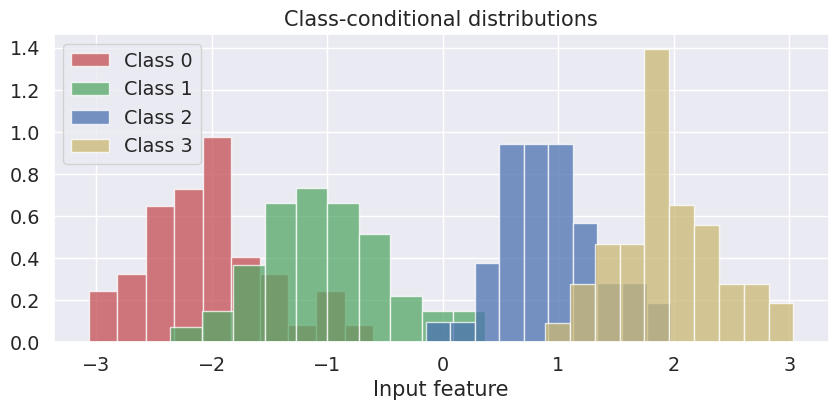

In [2]:
# seed
key = random.PRNGKey(123)
keys = random.split(key, 4) # create 4 keys for random number generation - one for each class

# number of classes and number of data points per class
num_classes = 4
M = 50

# generate simple synthetic toy dataset
xi = [-2 + 0.5*random.normal(keys[0], shape=(M, 1)),
      -1 + 0.5*random.normal(keys[1], shape=(M, 1)),
       1 + 0.5*random.normal(keys[2], shape=(M, 1)),
       2 + 0.5*random.normal(keys[3], shape=(M, 1))]
x = jnp.concatenate(xi)
y = jnp.hstack((jnp.zeros(M), jnp.ones(M), 2*jnp.ones(M), 3*jnp.ones(M)))

# specify input points for predictions
P = 300
xstar = jnp.linspace(-6, 6, P)

# plot
def plot_data(ax, title='Class-conditional distributions'):
    for i in range(4):
        ax.hist(xi[i], density=True, label='Class %d' % i, alpha=0.75, color=colors[i]);
    ax.set(xlabel='Input feature', title=title)
    ax.legend(loc='upper left');

fig, ax = plt.subplots(1,1, figsize=(10, 4))
plot_data(ax)

### Implementation

Below you are given a template for a class implementing the Laplace approximation for the linear classification model. The functions `log_prior` and `log_likelihood` takes a flat parameter vector $\mathbf{w}_{\text{flat}}$ as input and evaluate the log prior and log likelihood, respectively, for that parameter vector.

**Task 1.1**: Complete the implementation of the `log_prior` and `log_likelihood` functions in  the class `BayesianLinearSoftmax` below.

*Hints:*
- *All the parameters of the model are i.i.d. as $\mathcal{N}(0, \alpha^{-1})$ under the prior distribution.*
- *The class variable `y_onehot` contains a onehot-representations of $\mathbf{y}$*. 
- *Since we rely on JaX to compute the gradients and Hessian, you can only use `jax.numpy` functions in your implementation.* 
- *If you are encountering numerical problems, the softmax-function is likely the culprit. A simple way to make the computation $\text{softmax}(\mathbf{f})$ more robust is to subtract the maximum of $\mathbf{f}$ from each entry of $\mathbf{f}$ before carrying out the softmax operation, i.e. $\text{softmax}(\tilde{\mathbf{f}})$, where $\tilde{\mathbf{f}}_i = \mathbf{f}_i - \max_j \mathbf{f}_j$. for $i = 1, \dots, K$. There are several other ways of making softmax numerically safer, but this should not be necessary here.*

In [3]:
def log_npdf(x, m, v):
    return -0.5*(x-m)**2/v - 0.5*jnp.log(2*jnp.pi*v)

# convert from class label to one-hot encoding
def to_onehot(y, num_classes):
    return jnp.column_stack([1.0*(y==value) for value in jnp.arange(num_classes)])


# softmax transformation
def softmax(a_, axis=1):
    max_val = jnp.max(a_, axis=axis)                # get maximum value along axis
    a = a_ - jnp.expand_dims(max_val, axis=axis)    # subtract max value for numerical stability
    exp_a = jnp.exp(a)                                
    return exp_a/jnp.sum(exp_a, axis=axis)[:, None]


class BayesianLinearSoftmax(object):
    """ Bayesian linear softmax classifier with i.i.d. Gaussian priors """
    
    def __init__(self, X, y, alpha=1.):
        
        # data and prior
        self.X, self.y  = X, y
        self.N, self.D = self.X.shape
        self.alpha = alpha
        
        # num classes, num parameters and one-hot encoding
        self.num_classes = len(jnp.unique(y))
        self.num_params = self.num_classes * self.D
        self.y_onehot = to_onehot(self.y, self.num_classes)
        
        # fit
        self.compute_laplace_approximation()

    def log_prior(self, w_flat):
        """ Evaluates the log prior, i.e. log p(W). 
            The function accepts the argument w_flat, which is a flattened version of W, such that the shape of w_flat is (T,), where T = num_classes x D is the total number of parameters.
            The return value of the function must be a scalar.
        """
        log_prior_val = jnp.sum(log_npdf(w_flat, 0, 1./self.alpha))  

        # check dimensions and return
        assert log_prior_val.shape == ()
        return log_prior_val
        
    def log_likelihood(self, w_flat):
        """ Evaluates the log likelihood for dataset (self.X, self.y) using a Categorical distribution with softmax inverse link function
            The function accepts the argument w_flat, which is a flattened version of W, such that the shape of w_flat is (T,), where T = num_classes x D is the total number of parameters.
            The return value of the function must be a scalar.
        """
        
        # reshape from flat vector to matrix of size num_classes by D
        W = w_flat.reshape((self.num_classes, self.D))

        ##############################################
        # Your solution goes here
        ##############################################
        
        # compute values for each latent function
        y_all = self.X@W.T

        # normalize using softmax
        p_all = softmax(y_all)
        
        # evaluate 
        loglik_val =  jnp.sum(self.y_onehot*jnp.log(p_all))
        
        ##############################################
        # End of solution
        ##############################################

        # check dimensions and return
        assert loglik_val.shape == ()
        return loglik_val
        
    def log_joint(self, w_flat):
        return self.log_prior(w_flat) + self.log_likelihood(w_flat)
    
    def compute_laplace_approximation(self):
        """ computes Laplace approximation of model """

        w_init_flat = jnp.zeros(self.num_params)
        cost_fun = lambda W: -self.log_joint(W)
        result = minimize(value_and_grad(cost_fun), w_init_flat, jac=True)

        if result.success:
            w_MAP = result.x
            self.m_flat = w_MAP[:, None]    
            self.A_flat = hessian(cost_fun)(w_MAP)
            self.S_flat = jnp.linalg.inv(self.A_flat)
            return self.m_flat, self.S_flat
        else:
            print('Warning optimization failed')
            return None, None
    
    def predict_f(self, X_star):
        """ computes the posterior distribution of f_i(x, w) = w_i^T phi(x^*) for all K classes

            Arguments:
            X_star            --         PxD prediction points

            Returns
            mu_f_all_classes  --         posterior mean of f for all classes (shape: P x K)
            var_f_all_classes  --        posterior variance of f for all classes (shape: P x K)
         """
        
        # get relevant part for each of the K linear models
        mi = self.m_flat.reshape((self.num_classes, self.D))
        Si = [self.S_flat[i*self.D:(i+1)*self.D, i*self.D:(i+1)*self.D] for i in range(self.num_classes)]
    
        # compute mean and variance for each function
        mu_f_all_classes = X_star@mi.T
        var_f_all_classes = jnp.squeeze(jnp.stack([jnp.diag(X_star@Si[i]@X_star.T) for i in range(self.num_classes)], axis=1))

        return mu_f_all_classes, var_f_all_classes
    
    def generate_samples_f(self, X_star, num_samples=500, seed=456):
        """ generates samples from the posterior distribution p(f^*|y, x^*) based on the Laplace approximation
            
            Arguments:
            X_star            --         PxD prediction points
            num_samples       --         number of Monte Carlo samples to use
            seed              --         seed for random number generator

            Returns
            f_samples         --         posterior samples of f^*, shape: P x num_classes x num_samples         
        """

        # generate samples (shape: num_samples x total_params)
        w_samples_flat = random.multivariate_normal(key, self.m_flat.ravel(), self.S_flat, shape=num_samples)

        # reshape (shape: num_classes x D x num_samples)
        W_samples = w_samples_flat.T.reshape((self.num_classes, self.D, num_samples))

        # compute samples of f_star for all classes (shape: num_classes x P x num_samples)
        f_samples = X_star@W_samples

        # swap ax for convenience  (shape: P x num_classes x num_samples)
        f_samples = jnp.swapaxes(f_samples, 0, 1)

        return f_samples
                
    def predict_y(self, X_star, num_samples=500, seed=123):
        """ computes and returns p(y^*=k|y, x^*) using Monte Carlo sampling
         
            Arguments:
            X_star            --         PxD prediction points
            num_samples       --         number of Monte Carlo samples to use
            seed              --         seed for random number generator

            Returns
            p_all             --         Post. pred. probabilities for each point in X_star for each class, shape: PxK array, where K is the number of classes
        """
        # generate posterior samples of f* (shape: num_classes x P x num_samples)
        f_samples = self.generate_samples_f(X_star, num_samples, seed)
        
        ##############################################
        # Your solution goes here
        ##############################################
        
        # compute softmax for all individual samples (shape: P x num_classes x num_samples)
        p_all_samples = softmax(f_samples, axis=1)
        
        # compute mean over Monte Carlo samples  (shape: P x num_classes)
        p_all = p_all_samples.mean(2)
        
        ##############################################
        # End of solution
        ##############################################
        
        assert p_all.shape == (len(X_star), self.num_classes), f"The shape of p_all was expected to be ({len(X_star)}, {self.num_classes}), but the actual shape was {p_all.shape}. Please check the code"
        return p_all
    
# linear model with intercept and slope
design_matrix = lambda x: jnp.column_stack((jnp.ones(len(x)), x))
Phi = design_matrix(x)

# fit model and compute predictions
model = BayesianLinearSoftmax(Phi, y)

# print posterior mean for W
posterior_mean_W = model.m_flat.reshape((model.num_classes, model.D))
print('Posterior mean for W:\n', np.array2string(posterior_mean_W, precision=2))

Posterior mean for W:
 [[-1.31 -3.38]
 [ 1.55 -1.46]
 [ 1.51  1.23]
 [-1.75  3.61]]


If the previous task was solved correctly, the cell above should output the (approximate) posterior mean of the parameter matrix $\mathbf{W}$.

**Task 1.2**: Complete the implementation of the function `predict_y` for computing $p(y^*|\mathbf{y}, \mathbf{x^*})$ for an array of test points `X_star` above.

*Hints:*
-  *Use posterior samples of $f^*$ to estimate the posterior predictive probabilities using Monte Carlo estimation*
- *If you want to check your implementation of the previous task before attempting this one, you can comment out the lines `phat = ...` and `axes[2].plot(xstar, phat...`. If you do so, you should see a plot of the posterior distributions of the $K$ linear models.*
- *If you are struggling with this or don't know how to get started, ask for help or focus on the understanding the code in the solution instead.*

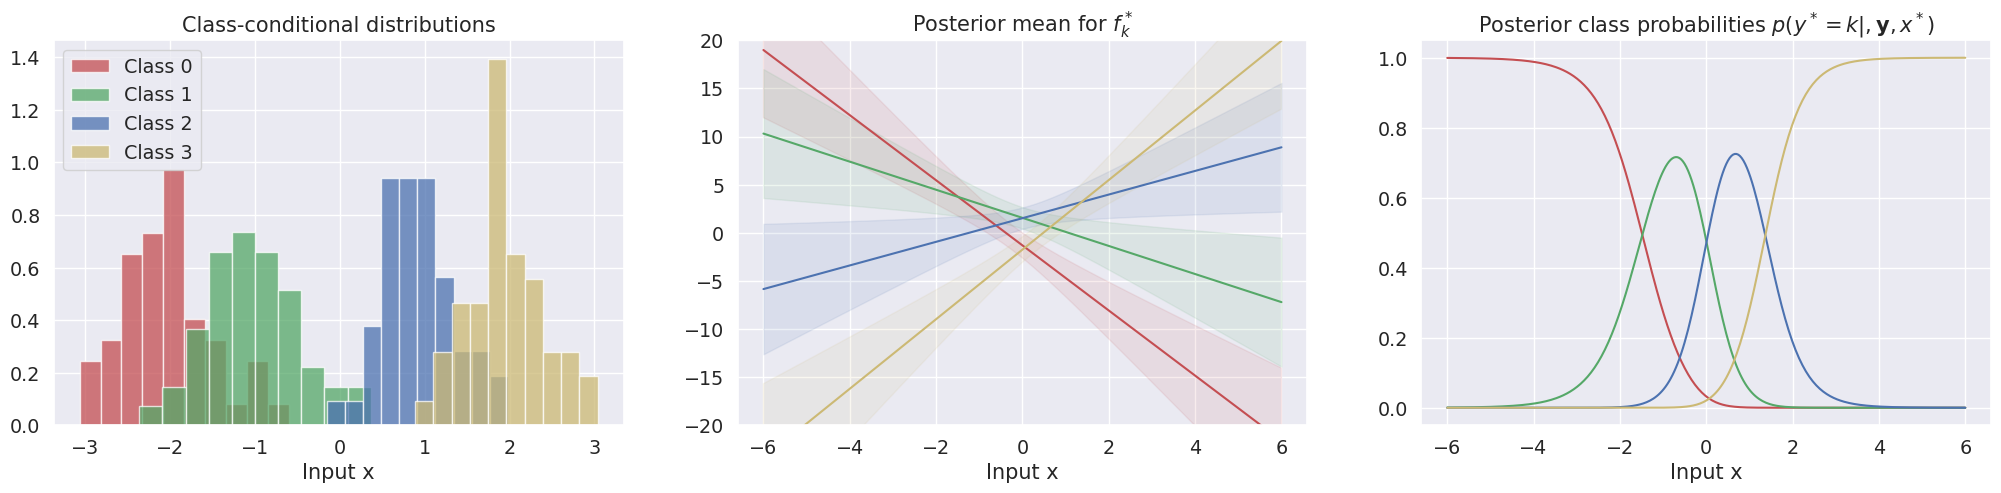

In [4]:
    # linear model with intercept and slope
design_matrix = lambda x: jnp.column_stack((jnp.ones(len(x)), x))
Phi, Phi_star = design_matrix(x), design_matrix(xstar)

# fit model and compute predictions
model = BayesianLinearSoftmax(Phi, y)
posterior_mu_f, posterior_var_f = model.predict_f(Phi_star)
posterior_class_probs = model.predict_y(Phi_star) # shape N x K

# plot
fig, ax = plt.subplots(1,3, figsize=(25, 5))
plot_data(ax[0])
for i in range(4):
    # plot posterior mean of latent function y for each class
    ax[1].plot(xstar, posterior_mu_f[:, i], label='i = %d' % i, color=colors[i])    
    ax[1].fill_between(xstar, posterior_mu_f[:, i]-1.96*jnp.sqrt(posterior_var_f[:, i]), posterior_mu_f[:, i]+1.96*jnp.sqrt(posterior_var_f[:, i]), alpha=0.1, color=colors[i])
    ax[2].plot(xstar, posterior_class_probs[:, i], label='i = %d' % i, color=colors[i])
    
for i in range(3):
    ax[i].set_xlabel('Input x')
ax[1].set(title='Posterior mean for $f^*_k$', ylim=(-20, 20))
ax[2].set_title('Posterior class probabilities $p(y^*=k|, \\mathbf{y}, x^*)$');

The previous task was solved correctly, the cell above should plot the posterior distribution of the latent functions $f_k(\mathbf{x})$ and the posterior class probabilities $p(y^*=k|\mathbf{y}, \mathbf{x}^*)$ for each class $k = 1, \dots, K$.

**Task 1.3**: Use the figures above to explain why the name "softmax" makes sense [**Discussion question**]


## Part 2:  A deeper dive into predictive uncertainty

As stated in Part 1, the **posterior predictive distribution** for a multi-class classification problem is a categorical distribution of the form
$$p(y^*|\mathbf{y}, \mathbf{x}^*)=\text{Cat}(y^*|\boldsymbol{\pi}),\quad\text{for}\quad\sum_{i=1}^K \boldsymbol{\pi}_i = 1\quad\text{and}\quad 0 \leq \boldsymbol{\pi}_i \leq 1,$$
where we estimated the class probabilities $p(y^*=k|\mathbf{y}, \mathbf{x}^*)=\pi_k$ using the Laplace approximation and Monte Carlo sampling.

We can quantify and summarize the **predictive uncertainty** using  **entropy** $\mathcal{H}$ from information theory, which for a **discrete random variable** is given by
$$\begin{align*}
\mathcal{H}\left[p(y^*|\mathbf{y}, \mathbf{x}^*)\right] = \mathcal{H}\left[\text{Cat}(y^*|\boldsymbol{\pi})\right]= -\sum_{i=1}^K \boldsymbol{\pi}_k \log \boldsymbol{\pi}_k,
\end{align*}$$
where we use the convention $0\log 0 = 0$ for the entropy calculation. 

We can also use the **confidence** $\mathcal{C}$, which is defined
$$
\mathcal{C}\left[p(y^*=k|\mathbf{y}, \mathbf{x}^*)\right] = \max\limits_{k\in\{ 1, \dots, K \}} p(y^*=k|\mathbf{y}, \mathbf{x}^*).
$$


Next, we will implement functions for computing the entropy $\mathcal{H}$ and confidence $\mathcal{C}$ for the predictive distributions in the toy example above for each value of $x$ in the vector `xstar` (similar to the rightmost plot above).

**Task 2.1**: Implement functions for `compute_entropy` and `compute_confidence` below. Comment on the relation between the confidence and entropy plots and the posterior predictive probabilities. 



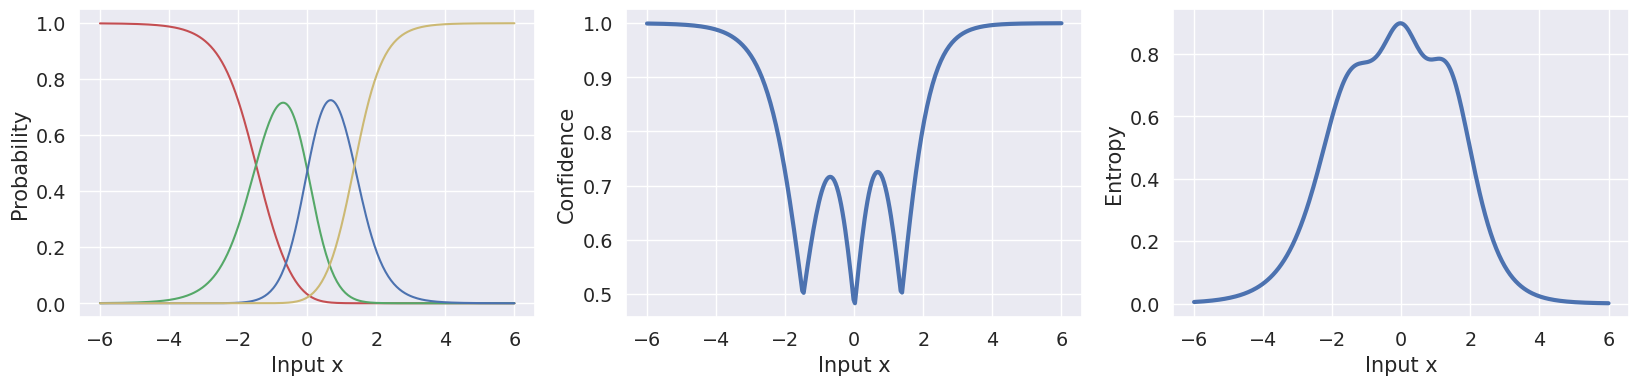

In [5]:

def compute_entropy(pi):
    """ assumes pi is [N, K] where N is the number of prediction points and K is the number of classes """ 
    log_pi = jnp.where(pi > 0, jnp.log(pi), 0)  # equal to log(p) when p > 0 else 0
    H = -jnp.sum(pi*log_pi, 1)
    return H

def compute_confidence(pi):
    """ assumes pi is [N, K] where N is the number of prediction points and K is the number of classes """
    return jnp.max(pi, 1)

# linear model with intercept and slope
design_matrix = lambda x: jnp.column_stack((jnp.ones(len(x)), x))
Phi, Phi_star = design_matrix(x), design_matrix(xstar)

# fit model and compute predictions
model = BayesianLinearSoftmax(Phi, y)
posterior_mu_f, posterior_var_f = model.predict_f(Phi_star)
posterior_class_probs = model.predict_y(Phi_star) # shape P x K

# evaluate confidence and entropy. The resulting shape should be (P,) for both input shape (P, K)
entropy = compute_entropy(posterior_class_probs)                
confidence = compute_confidence(posterior_class_probs)          

# check dimensions are compatible with plotting code below
assert entropy.shape == (len(Phi_star), ), f"Shape of entropy seems wrong. The actual shape is {entropy.shape}, but the expected to be of shape ({len(Phi_star)}, ). Please check your code"
assert confidence.shape == (len(Phi_star), ), f"Shape of confidence seems wrong. The actual shape is {confidence.shape}, but the expected to be of shape ({len(Phi_star)}, ). Please check your code"

# plot
fig, ax = plt.subplots(1, 3, figsize=(20, 4))
for i in range(4):
    ax[0].plot(xstar, posterior_class_probs[:, i], label='i = %d' % i, color=colors[i])
ax[0].set(xlabel='Input x', ylabel='Probability')
ax[1].plot(xstar, confidence, linewidth=3)
ax[1].set(xlabel='Input x', ylabel='Confidence')
ax[2].plot(xstar, entropy, linewidth=3)
ax[2].set(xlabel='Input x', ylabel='Entropy');

### Total uncertainty, aleatoric uncertainty, and epistemic uncertainty
Predictive uncertainty is often divided into two components: **aleatoric/irreducible** and **epistemic/reducible** uncertainty. The entropy of the predictive distribution defined above is sometimes referred to as the **total entropy** or **total uncertainty** since it contains both aleatoric (reducible) and epistemic (irreducible) uncertainty:
$$\mathcal{H}_{\text{total}} = \mathcal{H}\left[p(y^*| \mathbf{y}, \mathbf{x}^*)\right]=-\sum_{i=1}^K \pi_k \log \pi_k,$$
where $\mathcal{H}\left[\cdot\right]$ is the entropy operator, i.e. $\mathcal{H}\left[p\right]$ is the entropy of the distribution $p$.

For the Bayesian linear regression model in week 3, the expression for the analytical variance of the posterior predictive distribution naturally decomposed into aleatoric and epistemic uncertainty. We will now look into a similar decomposition based on entropy.

In the following, we will decompose the **total uncertainty** $\mathcal{H}_{\text{total}}$ additively into an **aleatoric** and **epistemic** component as follows:
$$\mathcal{H}_{\text{total}} = \mathcal{H}_{\text{aleatoric}}+ \mathcal{H}_{\text{epistemic}}.$$


We define the **aleatoric uncertainty** $\mathcal{H}_{\text{aleatoric}}$ to be
$$\mathcal{H}_{\text{aleatoric}} = \mathbb{E}_{p(\mathbf{W}|\mathbf{y})}\left[\mathcal{H}\left[p(y^*| \mathbf{W}, \mathbf{x}^*)\right]\right].$$

This expression looks a bit daunting, so let's remind ourselves of the notation:
- $p(\mathbf{W}|\mathbf{y})$ is the posterior distribution of parameters $\mathbf{W}$ given the observed data $\mathbf{y}$.
- $\mathbb{E}_{p(\mathbf{W}|\mathbf{y})}\left[\cdot\right]$ is the expectation wrt. to the posterior distribution $p(\mathbf{W}|\mathbf{y})$.
- $p(y^*| \mathbf{W}, \mathbf{x}^*)$ is the (predictive) likelihood of $y^*$, i.e. $\text{Cat}(y^*|\text{Softmax}(\mathbf{W}\phi(\mathbf{x}^*)))$, which is the distribution over the label $y^*$ given we know the new input point $\mathbf{x}^*$ and the parameters $\mathbf{W}$.
- $\mathcal{H}\left[p(y^*| \mathbf{W}, \mathbf{x}^*)\right]$ is the entropy of the likelihood.

Therefore, the aleatoric uncertainty $\mathcal{H}_{\text{aleatoric}}$ is the posterior expectation of the entropy of the likelihood, and this can easily be approximated using Monte Carlo-sampling:
$$\begin{align*}
\mathcal{H}_{\text{aleatoric}} =  \mathbb{E}_{p(\mathbf{W}|\mathbf{y})}\left[\mathcal{H}\left[p(y^*| \mathbf{W}, \mathbf{x}^*)\right]\right] \approx \frac{1}{S}\sum_{i=1}^S \mathcal{H}\left[p(y^*| \mathbf{W}^{(i)}, \mathbf{x}^*)\right] \quad\text{for}\quad \mathbf{W}^{(i)} \sim q(\mathbf{W}).
\end{align*}$$

This still looks scary, so let's unfold it further. Recall $\mathbf{f}_*^{(i)} = \mathbf{W}^{(i)}\phi(\mathbf{x}^*)$ and $\boldsymbol{\pi}^{(i)} = \text{softmax}\left(\mathbf{f}_*^{(i)}\right)$ denote the latent function values and the predictive probabilities, respectively, for the $i$'th posterior sample of the weights $\mathbf{W}^{(i)}$, and therefore, 
$$p(y^*| \mathbf{W}^{(i)}, \mathbf{x}^*)=\text{Cat}(y^*|\text{Softmax}(\mathbf{W}^{(i)}\phi(\mathbf{x}^*)))= \text{Cat}(y^*|\text{Softmax}(\mathbf{f}_*^{(i)})) = \text{Cat}(y^*|\boldsymbol{\pi}^{(i)})$$
and hence,  we can estimate the aleatoric uncertainty as
$$\begin{align*}
\mathcal{H}_{\text{aleatoric}} =  \mathbb{E}_{p(\mathbf{W}|\mathbf{y})}\left[\mathcal{H}\left[p(y^*| \mathbf{W}, \mathbf{x}^*)\right]\right] \approx \frac{1}{S}\sum_{i=1}^S \mathcal{H}\left[\text{Cat}(y^*|\boldsymbol{\pi}_*^{(i)})\right] = \frac{1}{S}\sum_{i=1}^S \mathcal{H}\left[\text{Cat}(y^*|\boldsymbol{\pi}^{(i)})\right],\tag{AU}
\end{align*}$$
where $\mathcal{H}\left[\text{Cat}(y^*|\boldsymbol{\pi}^{(i)})\right] = - \sum_{j=1}^K \pi^{(i)}_j \log \pi^{(i)}_j$.

That is, we compute the entropy of the predictive likelihood for each posterior sample and compute the mean.
 

Finally, we can define the **epistemic uncertainty** as the difference between the total uncertainty and the aleatoric uncertainty:

$$\begin{align*}
\mathcal{H}_{\text{epistemic}} &= \mathcal{H}_{\text{total}} - \mathcal{H}_{\text{aleatoric}} 
\end{align*}$$

The quantity $\mathcal{H}_{\text{epistemic}}$ has some desirable properties:

1) If the posterior variances collapses (i.e the posterior approaces a Dirac delta distribution), then  $\mathcal{H}_{\text{epistemic}}$ goes to 0.

2) It quantifies how the total uncertainty would be reduced if we knew the true parameters

3) The epistemic uncertainty will generally be large in region with little (or conflicting) evidence/data.

4) It does not depend on analytical tractability, so we can compute it for any probabilistic model.

Thus, the epistemic uncertainty can be very useful for understanding when our predictions are out-of-distribution (OOD), when we can get better predictions by collecting more data etc.


### Let's summary the key equations

Let $\mathbf{f}_*^{(i)} = \mathbf{W}^{(i)}\phi(\mathbf{x}^*)$ and $\boldsymbol{\pi}^{(i)} = \text{softmax}\left(\mathbf{f}_*^{(i)}\right)$ for posterior samples of the parameters $\mathbf{W}^{(i)} \sim q(\mathbf{W})$, then
$$\begin{align*}
\boldsymbol{\pi} &= \frac{1}{S}\sum_{i=1}^S \boldsymbol{\pi}^{(i)},\\
\mathcal{H}_{\text{total}} &=\mathcal{H}\left[\text{Cat}(y^*|\boldsymbol{\pi})\right]\tag{TU},\\
\mathcal{H}_{\text{aleatoric}} &=  \frac{1}{S}\sum_{i=1}^S \mathcal{H}\left[\text{Cat}(y^*|\boldsymbol{\pi}^{(i)})\right]\tag{AU},\\
\mathcal{H}_{\text{epistemic}} &= \mathcal{H}_{\text{total}} - \mathcal{H}_{\text{aleatoric}}. \tag{EU}
\end{align*}$$


Now, let's compute and visualize the following three quantities: $\mathcal{H}_{\text{total}}$, $\mathcal{H}_{\text{aleatoric}}$, and $\mathcal{H}_{\text{epistemic}}$

**Task 2.2**: Complete the implementation of `H_total`, `H_aleatoric`, and `H_epistemic` below. 

*Hints*:
- *Consider re-using your implementation of `compute_entropy` from the previous task*
- *All three quantities can be computed relatively easily given Monte Carlo samples from the posterior of $\mathbf{f}^*$*
- *If you don't know how to get started, ask for help or look at the solution*.

In [6]:
# linear model with intercept and slope
design_matrix = lambda x: jnp.column_stack((jnp.ones(len(x)), x))


design_matrix = lambda x: jnp.column_stack((jnp.ones(len(x)), x, x**2, x**3, x**4))


# fit model and compute predictions
model = BayesianLinearSoftmax(design_matrix(x), y)
posterior_mu_f, posterior_var_f = model.predict_f(design_matrix(xstar))
posterior_class_probs = model.predict_y(design_matrix(xstar))

# generate samples of f* (shape: P x num_classes x num_samples)
num_samples = 500
f_samples = model.generate_samples_f(design_matrix(xstar), num_samples)

# compute softmax probabilities per sample (shape: P x num_classes x num_samples)
pi_samples = softmax(f_samples, axis=1)  

# compute uncertainties, shape for all three should be (P, ) to be compatible with the plotting code in the next cell
H_total = compute_entropy(jnp.mean(pi_samples, axis=2))      
H_aleatoric = jnp.mean(compute_entropy(pi_samples), axis=1)  
H_epistemic = H_total - H_aleatoric                  

# store in dictionary for later use
uncertainties = {   'total': H_total,
                    'aleatoric': H_aleatoric,
                    'epistemic': H_epistemic,
                }

# sanity check for dimensions and range of values
for name, uq_array in uncertainties.items():
    assert uq_array.shape == (P,), f"The variable H_{name} was expected to be a JaX array of shape (P,) where P is the length of xstar, but the actual shape was {uq_array.shape}. Please check your code"
    assert jnp.all(uq_array >= 0), f"The values in H_{name} should be non-negative, but the smallest value was {jnp.min(uq_array):.4f}"
    assert jnp.all(uq_array <= jnp.log(4)), f"The values in H_{name} should less than {jnp.log(4):.4f}, but the largest value was {jnp.max(uq_array):.4f}"
print('Shapes and range of H_total, H_aleatoric, H_epistemic seem ok.')

Shapes and range of H_total, H_aleatoric, H_epistemic seem ok.


If the code above has been implemented correct, the cell below should plot the following:
- histogram of input data for each class
- posterior class probabilities
- the total uncertainty, aleatoric uncertainty and epistemic uncertainty

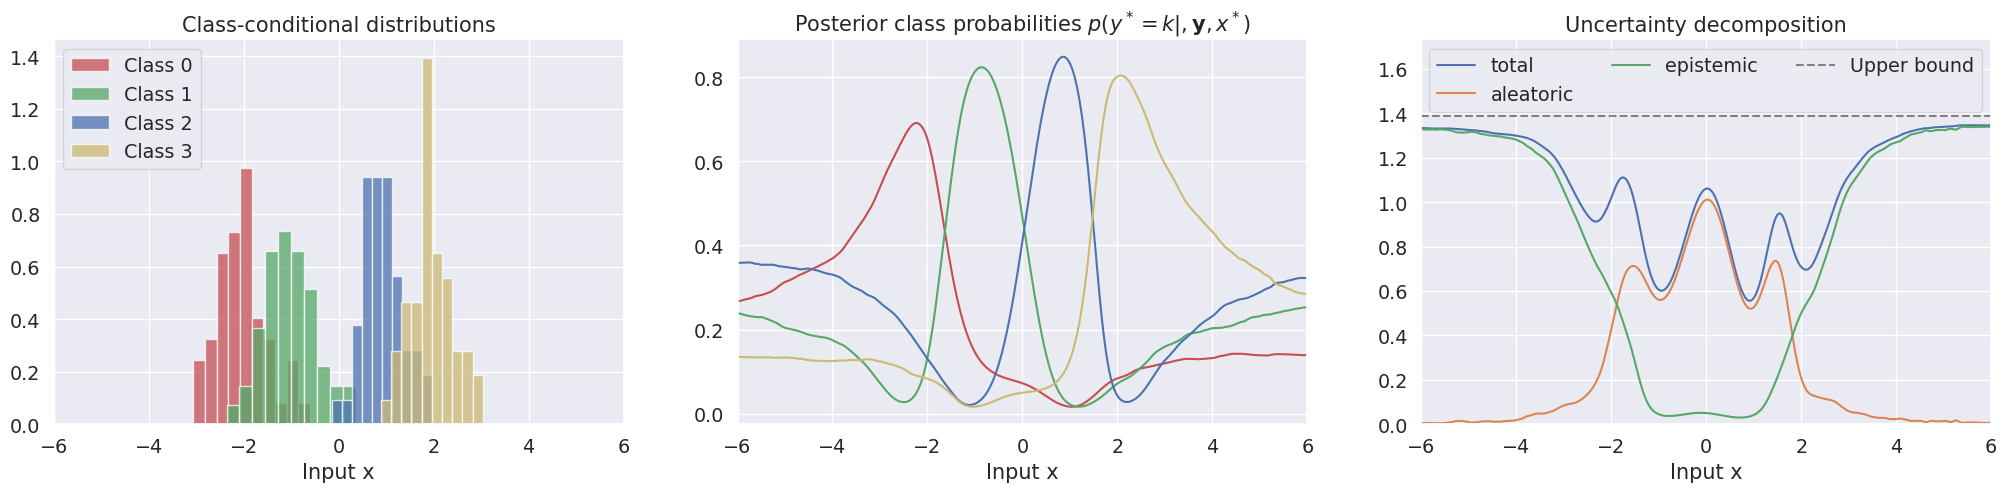

In [7]:
# make plot
fig, ax = plt.subplots(1,3, figsize=(25, 5))

# data distributions
plot_data(ax[0])

# plot posterior class probs
for i in range(4):
    ax[1].plot(xstar, posterior_class_probs[:, i], label='i = %d' % i, color=colors[i])

# plot uncertainty decomposition
for name, uq_array in uncertainties.items():
    ax[2].plot(xstar, uq_array, label=f'{name}')
ax[2].axhline(jnp.log(4), linestyle='--', color='k', alpha=0.5, label='Upper bound')

# labels, titles and legends
for i in range(3):
    ax[i].set(xlabel='Input x', xlim=(-6, 6))
ax[1].set_title('Posterior class probabilities $p(y^*=k|, \\mathbf{y}, x^*)$');
ax[2].set(title='Uncertainty decomposition', ylim=(0, 1.25*jnp.log(4)));
ax[2].legend(ncols=3);

**Task 2.3**: What dominates the total uncertainty? The aleatoric or the epistemic uncertainty? [**Discussion question**]

**Task 2.4**:  What happens if you can back up and change the feature representation to include non-linear features, e.g. $\phi(\mathbf{x}) = \begin{bmatrix} 1 & x & x^2 & x^3 & x^4 \end{bmatrix}$? What happens to the aleatoric and epistemic component when you include non-linear features? Can you explain what you see? [**Discussion question**]


Next, we will turn our attention to decision theory.

## Part 3:  Bayesian decision theory for classification

Making a decision for multi-class classification entails assigning a class label $\hat{y}^* \in \left\lbrace 1, 2, \dots, K\right\rbrace$ to a new test point $\mathbf{x}^*$. In Bayesian decision theory, the utility function $\mathcal{U}(y^*, \hat{y})$ specifies the **utility** (i.e. gain) for predicting $\hat{y}^*$ when the true target is $y^*$.

In practice, we don't know the true target $y^*$, but the predictive posterior distribution $p(y^*|\mathbf{y}, \mathbf{x}^*)$ contains all the relevant knowledge about $y^*$ given our observed data $\mathbf{y}$. Therefore, we compute the **expected utility** wrt. the posterior predictive distribution for each possible value of $\hat{y}$ and then assign the class label that **maximizes the expected utility**. That is,

\begin{align*}
\hat{y}^* = \arg\max\limits_{k \in \left\lbrace 1, 2, \dots, K\right\rbrace} \mathbb{E}_{p(y^*|\mathbf{y}, \mathbf{x}^*)}\left[\mathcal{U}(y^*, \hat{y}=k)\right]
\end{align*}

Since $p(y^*|\mathbf{y}, \mathbf{x}^*)$ is a discrete probability distribution with probabilities $p(y^* = k|\mathbf{y}, \mathbf{x}^*) = \pi_k$, expectations with respect to $p(y^*|\mathbf{y}, \mathbf{x}^*)$ is simply a weighted sum.

In the videos we saw that in order to make optimal decisions under the **0/1-utility function** (remember utility is just negative loss and vice versa), we simply have to pick the class label with largest posterior probability. Let's investigate this empirically and study how the decision regions change when we change the utility-function.

**Task 3.1**: Complete the implementation of the function `compute_expected_utility`

*Hints: How do we compute expectations with respect to discrete distributions?*

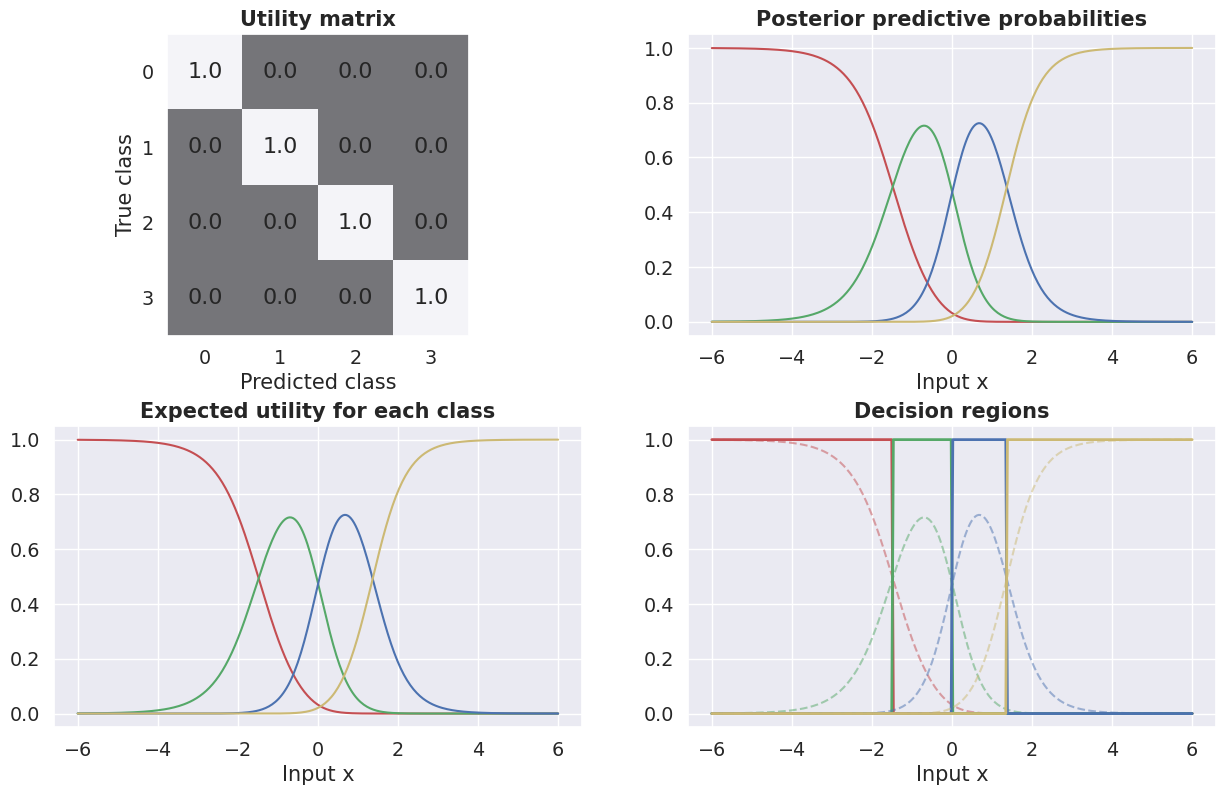

In [8]:
def compute_expected_utility(U, phat):
    """ computes the expected utility for a multi-class classification problem with K classes for utility matrix U and posterior predictive probabilities phat 
        
        Arguments
        U               --      Utility matrix (shape: [K x K])
        phat            --      Posterior predictive probabilities (shape: [P x K]), where P is the number of prediction points

        expected_util   --      Expected utility for each class for each point in phat (shape: P x K)           
           """
    

    expected_util = phat@U  

    # check dimensions and return
    assert expected_util.shape == phat.shape, f'The variable expected_util was expected to have shape {phat.shape}, but the actual shape was {expected_util.shape}. Please check your code.'
    return expected_util

# define utility matrix
U = jnp.identity(num_classes)


#######################################
# Solution
#######################################
#U = jnp.identity(num_classes)
# U = U.at[0, 1].set(-1)
# U = U.at[0, 1].set(-2)


#######################################
# Solution
#######################################
#U = jnp.identity(num_classes)
# U = U.at[2,3].set(1)
# U = U.at[3,2].set(1)


#######################################
# Solution
#######################################
#U = jnp.identity(num_classes)
# U = U.at[1,1].set(0.5)


# linear model with intercept and slope
design_matrix = lambda x: jnp.column_stack((jnp.ones(len(x)), x))
Phi, Phi_star = design_matrix(x), design_matrix(xstar)

# fit model and compute predictions
model = BayesianLinearSoftmax(Phi, y)
posterior_class_probs = model.predict_y(Phi_star)

# compute the expected utility for each class
expected_utility = compute_expected_utility(U, posterior_class_probs) 

# make decisions
decisions = to_onehot(jnp.argmax(expected_utility, axis=1), num_classes)
    
# plot everything
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# utility matrix
visualize_utility(axes[0,0], U)

# posterior predictive probs
for i in range(num_classes):
    axes[0,1].plot(xstar, posterior_class_probs[:, i], color=colors[i])
axes[0,1].set_title('Posterior predictive probabilities', fontweight='bold')
axes[0,1].set_xlabel('Input x')

# expected utility
for i in range(num_classes):
    axes[1,0].plot(xstar, expected_utility[:, i], color=colors[i]);
axes[1,0].set_title('Expected utility for each class', fontweight='bold')
axes[1, 0].set_xlabel('Input x')

# decisions
for i in range(num_classes):
    axes[1,1].plot(xstar, decisions[:, i], color=colors[i], linewidth=2);
    axes[1,1].plot(xstar, posterior_class_probs[:, i], color=colors[i], alpha=0.5, linestyle='--')
axes[1,1].set_title('Decision regions', fontweight='bold')
axes[1,1].set_xlabel('Input x')
fig.subplots_adjust(hspace=0.3)

**Task 3.2**: Use the figure above to explain how Bayesian decision theory works for multi-class classification. [**Discussion question**]

**Task 3.3**: What happens to the expected utilities and to the decisions if you scale the utility matrix by a positive constant? [**Discussion question**]

**Task 3.4**: What happens to the decision boundary if you introduce a negative utility of $-1$ for predicting 1 (green), when the true target is 0 (red)? What about $-2$? [**Discussion question**]

**Task 3.5**: What happens if you change the 0/1 utility function to have $U_{23} = U_{32} = 1$? [**Discussion question**]

**Task 3.6**: What happens if you change the 0/1 utility function to have $U_{11} = 0$? or to $U_{11} = 0.5$? [**Discussion question**]

## Part 4:  Image classification

It's now time to apply the material from part 1 and part 2 to a real dataset. Specifically, we will work with a subset of the Linnaeus 5 dataset (http://chaladze.com/l5/). The original Linnaeus 5 dataset contains images of size 256x256 from 5 classes, but we will work with a subset of this dataset containing a total of 3200 images in 4 classes (dogs, birds, flowers, berries). The images have been resized to 128x128 with the sole purpose of reducing the size of the data file. 

We will use **transfer learning** and use a pretrained ResNet18-network as a **feature extractor** for the images. ResNet18 is a convolutional neural network with 18 layers, which has been trained on a huge image dataset called ImageNet. The ImageNet containes images from 1000 different classes, which means that the very last layer of the ResNet architecture is a softmax-layer with 1000 outputs. However, if we get rid of the very last layer, we can use the rest of the network as a general feature extractor for images. That is, we propagate each image through the network we can use the very last hidden layer as a 512-dimensional feature vector for the image.

The details of how this works beyond what's written above is **not** part of the curriculum of the course and therefore, we have pre-computed feature vectors for all the images for you. 

However, if you are interested in the details, you can look at the following resources:

- Code used for feature extraction [here](https://github.com/christiansafka/img2vec)
- Paper describing the ResNet architecture [here](https://arxiv.org/pdf/1512.03385.pdf)
- A Pytorch tutorial for transfer learning for vision problems [here](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html#sphx-glr-beginner-transfer-learning-tutorial-py)


Let's load the data

In [9]:
data = jnp.load('./ex7_data.npz')
labels = list(data['labels'])
targets = data['targets']
num_classes = data['num_classes'][()]

img_train, img_test = data['Xtrain'], data['Xtest']
ytrain, ytest = data['ttrain'], data['ttest']
train_idx = data['train_idx']
test_idx = data['test_idx']

N, D = img_train.shape
Ntest = len(img_test)
print(f'Number of images for training: {N}')
print(f'Number of images for test: {Ntest}')
print(f'Number of features: {D}')
print(f'Number of clases: {num_classes}')


Number of images for training: 320
Number of images for test: 2880
Number of features: 512
Number of clases: 4


.. and plot a few examples

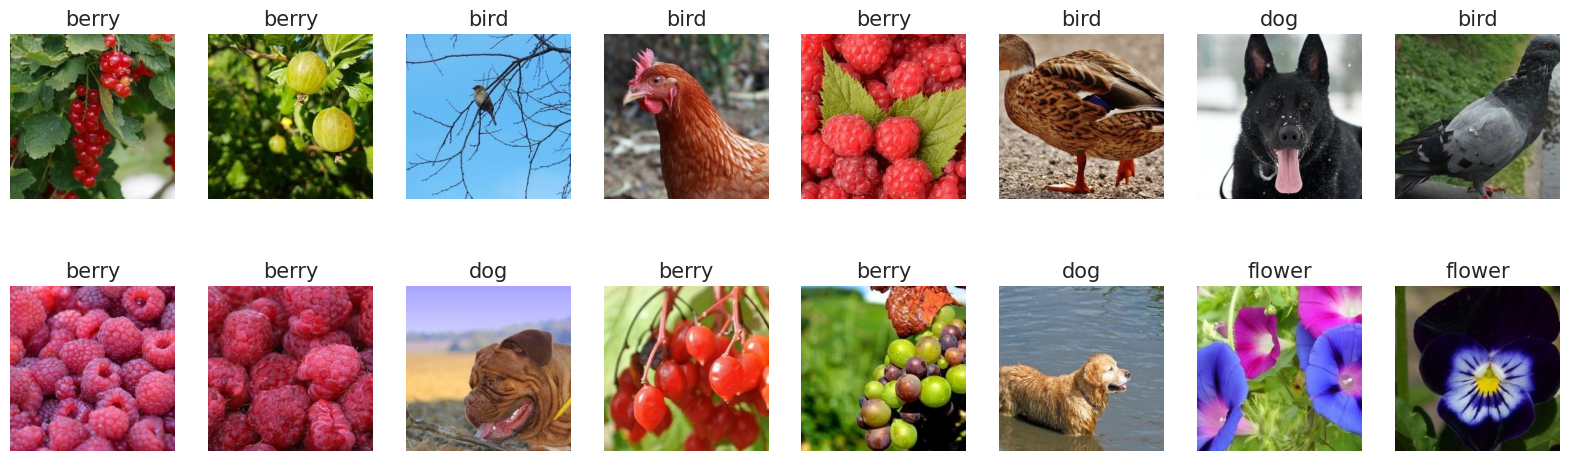

In [10]:
def show_example(ax, i):
    """ show training example i """
    
    j = train_idx[i]
    img = Image.open('./images/%d.jpg' % j)
    target = targets[j]
    ax.imshow(img)
    ax.set_title(labels[int(target)])
    ax.grid(False)
    ax.axis('off')

fig, ax = plt.subplots(2, 8, figsize=(20, 6))
for i in range(16):
    show_example(ax.flat[i], i)

Each image is represented using a 512-dimensional feature vector, but we will (again) reduce the dimensionality to $D = 2$ using principal component analysis (PCA) for the purpose of visualization.

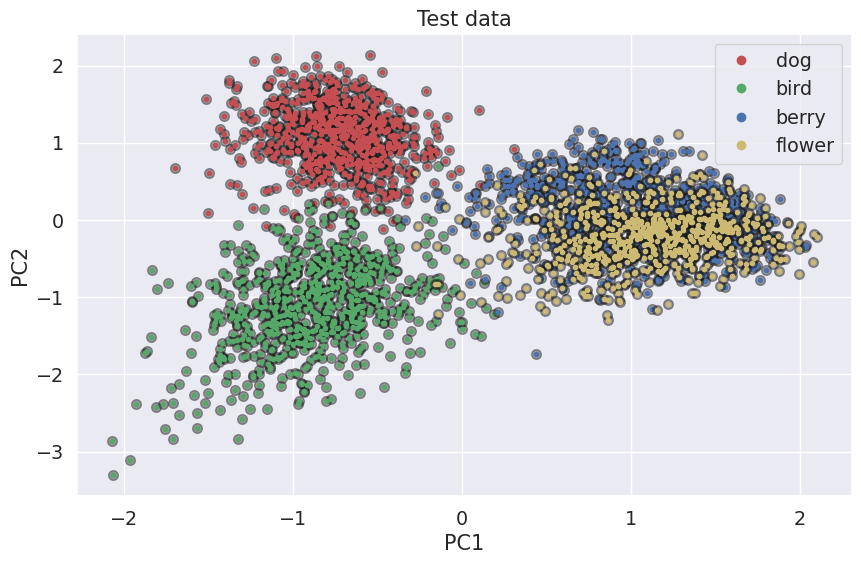

In [11]:
Ztrain, Ztest = PCA_dim_reduction(img_train, img_test, num_components=2)

def plot_pca_data(ax, legend=True, alpha=1):

    for i in range(num_classes):
        ax.plot(Ztest[ytest==i, 0], Ztest[ytest==i, 1], '.', color='k', markersize=14, alpha=0.4)
        ax.plot(Ztest[ytest==i, 0], Ztest[ytest==i, 1], '.', color=colors[i], label=labels[i], markersize=6, alpha=alpha)
    if legend:
        ax.legend(markerscale=2)
    ax.set(xlabel='PC1', ylabel='PC2')
    ax.set_title('Test data')

fig, ax = plt.subplots(figsize=(10, 6))
plot_pca_data(ax);


Let's  fit the model and visualize the posterior class probabilitites.

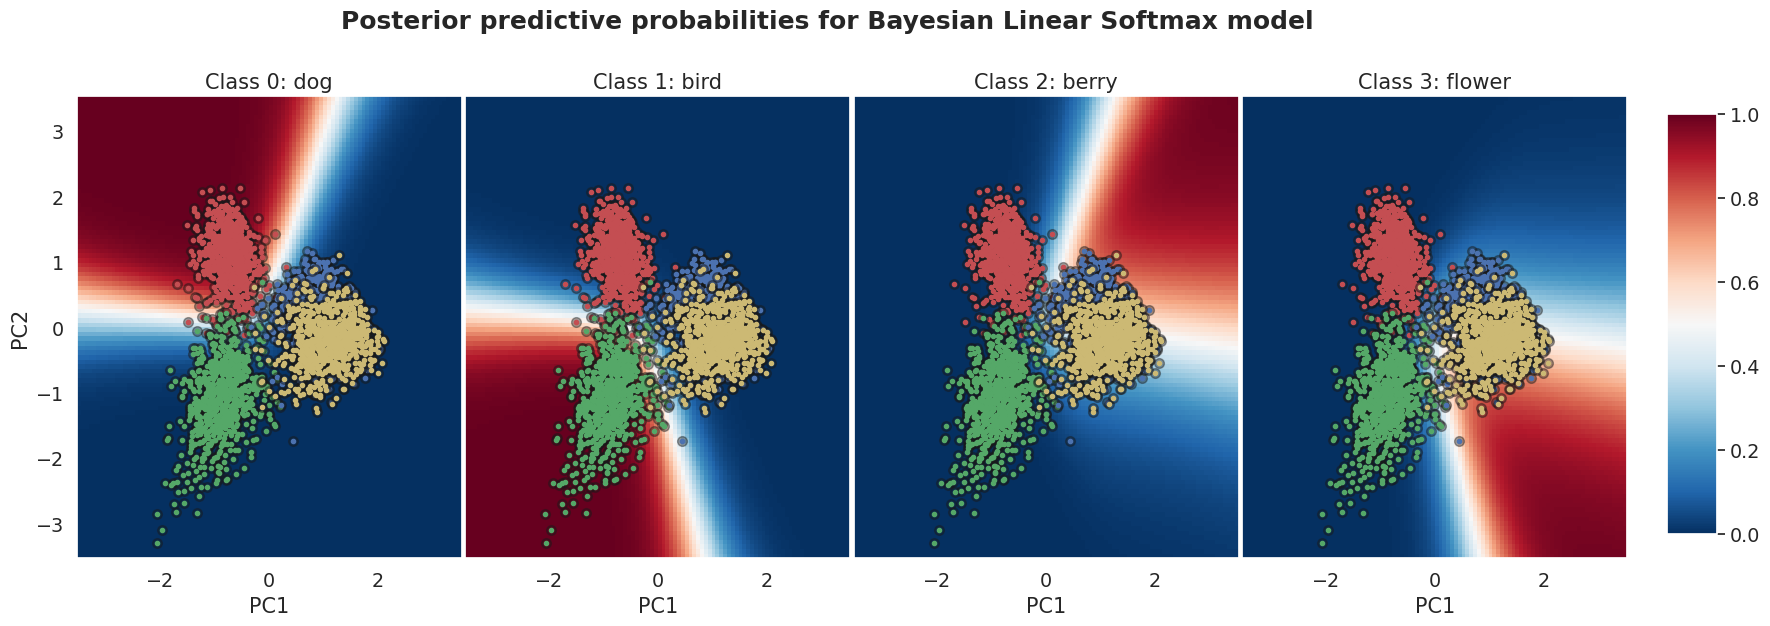

In [12]:
def visualize_regions(x_grid, posterior_class_probs, name, show_data=True):
    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 6))
    for i in range(num_classes):
        
        probs_reshaped =  posterior_class_probs[:, i].reshape((len(x_grid), len(x_grid)))
        im = axes[i].pcolormesh(x_grid, x_grid,probs_reshaped, cmap=plt.cm.RdBu_r, clim=(0, 1), shading='auto')

        if show_data:
            plot_pca_data(axes[i], legend=False)
        axes[i].set_title('Class %d: %s' % (i, labels[i]))

        if i > 0:
            axes[i].set_yticklabels([])
            axes[i].set_ylabel('')

    fig.subplots_adjust(right=0.9, wspace=0.01)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.025, 0.7])
    fig.colorbar(im, cax=cbar_ax);
    fig.suptitle(name, fontweight='bold', y=1.025)
        
# we want to have an intercept in the model
X_train, X_test = design_matrix(Ztrain), design_matrix(Ztest)
 
# prepare grid for making predictions
x_grid = jnp.linspace(-3.5, 3.5, 100)
XX1, XX2 = jnp.meshgrid(x_grid, x_grid)
Xp = jnp.column_stack((XX1.ravel(), XX2.ravel()))
X_pred = design_matrix(Xp)

# Fit linear classifier
model = BayesianLinearSoftmax(X_train, ytrain)
p_pred = model.predict_y(X_pred)

# visualize the posterior class proabilities for each model
visualize_regions(x_grid, p_pred, 'Posterior predictive probabilities for Bayesian Linear Softmax model')

**Task 4.1**: Compute predictions (wrt. the 0/1-utility function) and compute the accuracy for the training and test set.

**Solution**

In [13]:
def compute_accuracy(y_true, y_pred):
    return jnp.mean(y_true.ravel() == y_pred.ravel())

# evalaute class probabilities for training and test set using Bayesian linear softmax
p_train = model.predict_y(X_train)
p_test = model.predict_y(X_test)

# classify using 0/1 utility function
ytrain_hat = jnp.argmax(p_train, axis=1)
ytest_hat = jnp.argmax(p_test, axis=1)

# compute and print accuracy
print('Accuracy training:\t%3.2f' % compute_accuracy(ytrain, ytrain_hat))
print('Accuracy test:\t\t%3.2f' % compute_accuracy(ytest, ytest_hat))

Accuracy training:	0.85
Accuracy test:		0.80


**End of solution**

**Task 4.2**: Compute and plot the **entropy** and **confidence** for the predictions in the plot above. In which areas of the input space is this model most uncertain about the class label?

**Solution**

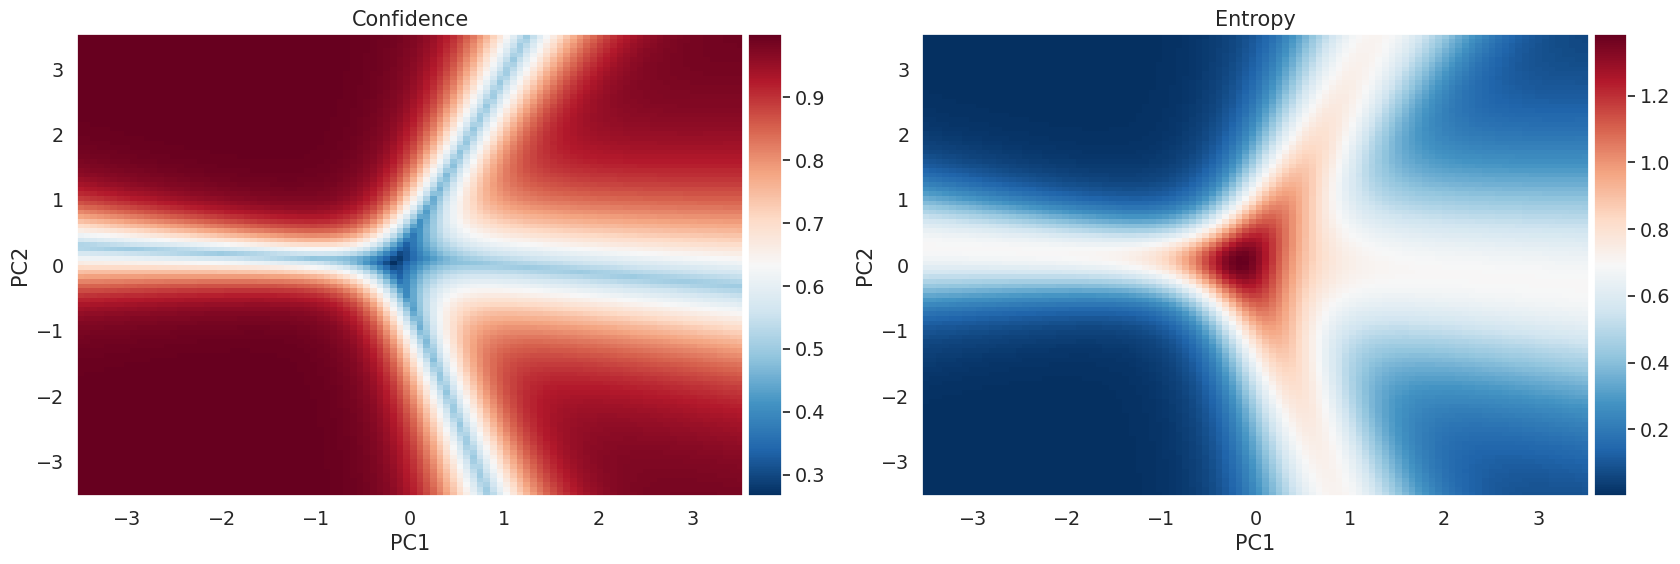

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
im0 = ax[0].pcolormesh(x_grid, x_grid, compute_confidence(p_pred).reshape((len(x_grid), len(x_grid))), shading='auto', cmap=plt.cm.RdBu_r)
im1 = ax[1].pcolormesh(x_grid, x_grid, compute_entropy(p_pred).reshape((len(x_grid), len(x_grid))), shading='auto', cmap=plt.cm.RdBu_r)
ax[0].set(xlabel='PC1', ylabel='PC2', title='Confidence')
ax[1].set(xlabel='PC1', ylabel='PC2', title='Entropy');
add_colorbar(im0, fig, ax[0])
add_colorbar(im1, fig, ax[1])



**End of solution**

**Task 4.3**: Compute the average confidence for the training set and test set and compare with the accuracy results

**Solution**

In [15]:
print('Avg. confidence training: %3.2f' % jnp.mean(compute_confidence(p_train)))
print('Avg. confidence test: %3.2f' % jnp.mean(compute_confidence(p_test)))

Avg. confidence training: 0.79
Avg. confidence test: 0.76


**End of solution**

## Part 5:  Making decisions with a reject option

Next, we will investigate how to make decisions with a **reject** option, meaning we avoid to making any decisions if the confidence is below a specified threshold $p_{\text{reject}}$.

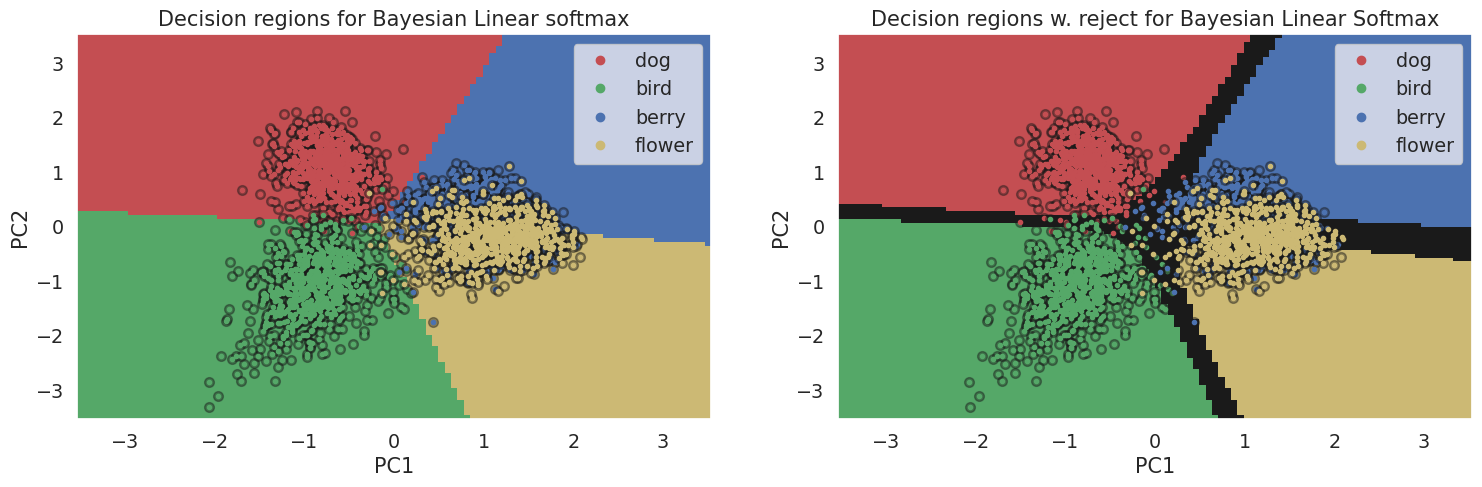

In [16]:
# specify reject threshold
p_reject = 0.6

# compute decisions under 0/1-utility function and reshape to grid
decisions = jnp.argmax(p_pred, axis=1).reshape((len(x_grid), len(x_grid)))

# identify reject regions
p_pred_confidence = compute_confidence(p_pred) # use the function you implemented earlier
reject_region_bls = 1.0*jnp.logical_not((p_pred_confidence < p_reject).reshape((len(x_grid), len(x_grid))))
decisions_with_reject = (decisions+1)*reject_region_bls

# visualize
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))
plot_pca_data(axes[0])
axes[0].pcolormesh(x_grid, x_grid, decisions, cmap=ListedColormap(colors), alpha=1, shading='auto')
axes[0].set_title('Decision regions for Bayesian Linear softmax')
plot_pca_data(axes[1]);
axes[1].pcolormesh(x_grid, x_grid, decisions_with_reject, cmap=ListedColormap(['k'] + colors), shading='auto')
axes[1].set_title('Decision regions w. reject for Bayesian Linear Softmax');



**Task 5.1**: Explain what you see in the figure above - relate the **reject region** in black to the confidence plot above [**Discussion question**]



**Task 5.2**: What happens to the reject region if you increase or decrease the reject threshold?  [**Discussion question**]


**Task 5.3**: How many percent of the samples in the test set are rejected with $p_{\text{reject}} = 0.6$?

**Solution**


In [17]:
test_set_reject_idx = compute_confidence(p_test) < p_reject
test_set_keep_idx = compute_confidence(p_test) >= p_reject
print('Fraction of sample rejected: %3.2f' %jnp.mean(test_set_reject_idx))

Fraction of sample rejected: 0.28


**End of solution**

**Task 5.4**: What is the accuracy for the samples in the test set, which are not rejected?

**Solution**

In [18]:
ytest_keep = ytest[test_set_keep_idx]
ptest_keep = p_test[test_set_keep_idx]
ytest_keep_hat = jnp.argmax(ptest_keep, axis=1)

print('Accuracy for kept samples:\t\t%3.2f' % compute_accuracy(ytest_keep, ytest_keep_hat))

Accuracy for kept samples:		0.89


**End of solution**

**Task 5.5**: If we were to make a decision for the test samples in the reject region, what would the accuracy rate be? 

**Solution**


In [19]:
ytest_reject = ytest[test_set_reject_idx]
ptest_reject = p_test[test_set_reject_idx]
ytest_reject_hat = jnp.argmax(ptest_reject, axis=1)

print('Accuracy for rejected samples:\t\t%3.2f' % compute_accuracy(ytest_reject, ytest_reject_hat))

Accuracy for rejected samples:		0.58


**End of solution**


**Task 5.6**: Instead, if the reject option, implement the following utility function and plot the corresponding decision boundaries:

- Utility of 1 for correctly classifying dogs, birds, and flowers
- Utility of 2 for correctly classifying berries
- Utility of 0 for all misclassifications



**Solution**

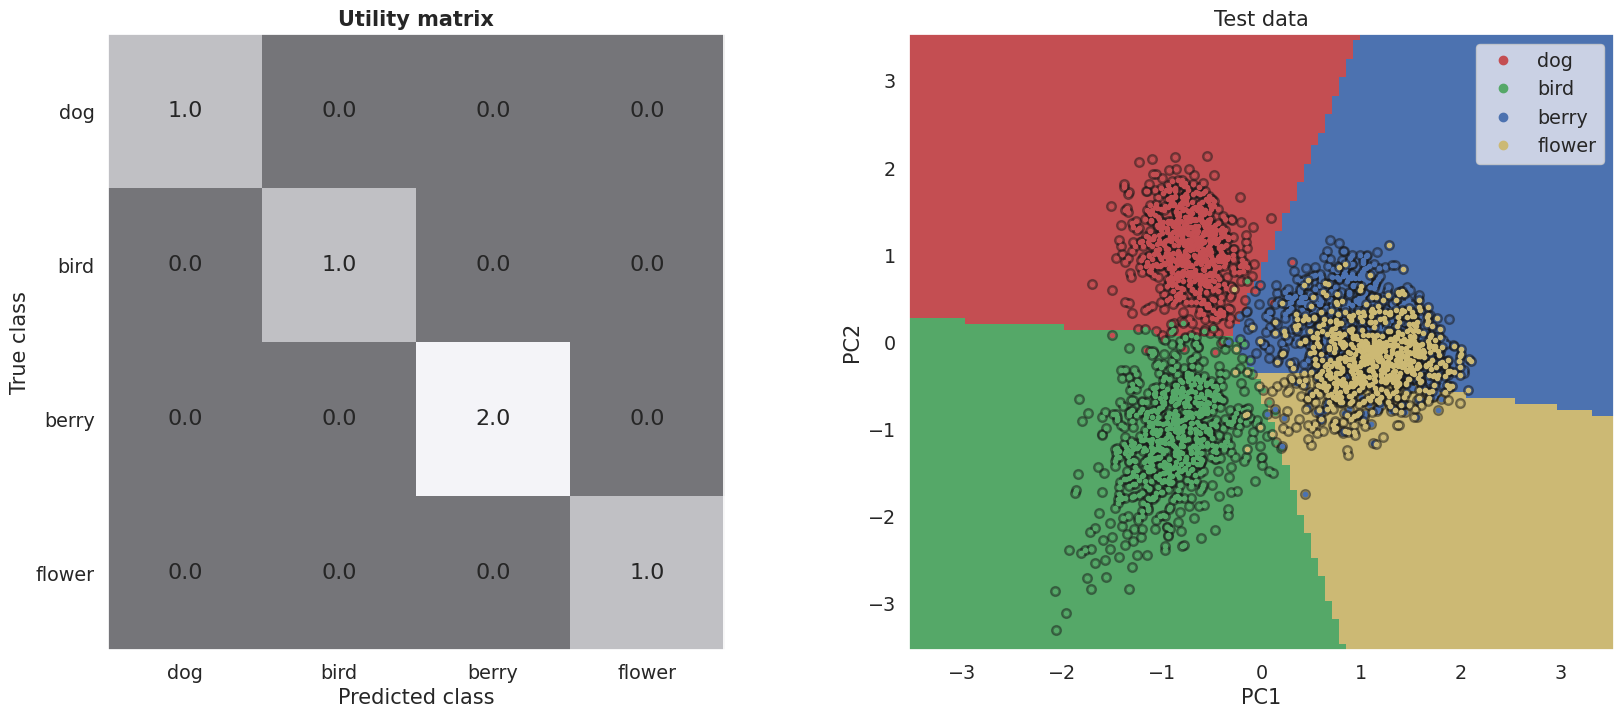

In [20]:
# specify utility  functions
U = jnp.identity(4)
U = U.at[2,2].set(2)

# compute the expected utility for each class for each utility function
expected_utility = compute_expected_utility(U, p_pred)

# make decisions and reshape
decisions = jnp.argmax(expected_utility, axis=1).reshape((len(x_grid), len(x_grid)))

# plot
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
visualize_utility(axes[0], U, labels=labels)
axes[1].pcolormesh(x_grid, x_grid, decisions, cmap=ListedColormap(colors), alpha=1, shading='auto')
axes[1].set_title('Decision regions for $U_{%d}$' % (i+1))
plot_pca_data(axes[1]);


**End of solution**

## Part 6:  Model calibration

As we have seen, the posterior predictive probabilities play a key role in decision-making. In the last part of this exercise, we will study calibration of these probabilities using the **expected calibration error (ECE)**-metric and so-called **reliability plots** (see Section 14.2.2.1 or pages 578 in Murphy2).

In this exercise, we will use the test set $\left\lbrace \mathbf{x}_m^*, y^*_m \right\rbrace_{m=1}^M$ to evaluate these metrics. Let $\hat{y}^*_m = \arg\max_k p(y^*_m = k|\mathbf{y}, \mathbf{x}^*m)$ be the decision (under the 0/1-utility function) for the $m$'th test point and let $\mathcal{C}_m = \max_k p(y^*_m = k|\mathbf{y}, \mathbf{x}^*_m)$ be the corresponding confidence. We will divide the unit interval in $B$ bins and estimate the average accuracy and confidence for each bin:

$$\begin{align*}
\text{acc}(\mathcal{B}_b) &= \frac{1}{|\mathcal{B}_b|} \sum_{m \in \mathcal{B}_b} \mathbb{I}\left(\hat{y}^*_m = y^*_m\right)\\
\text{conf}(\mathcal{B}_b) &= \frac{1}{|\mathcal{B}_b|} \sum_{m \in \mathcal{B}_b} \mathcal{C}_m,
\end{align*}$$

where $\mathcal{B}_b$ contains all the indices of points falling into the $b$'th bin. Then the ECE is defined as

$$\begin{align*}
\text{ECE} = \sum_{b=1}^B \frac{|\mathcal{B}_b|}{M}|\text{acc}(\mathcal{B}_b) - \text{conf}(\mathcal{B}_b)|.
\end{align*}$$

**Note**: The ECE is **not** a so-called *proper scoring rule*, and therefore, we cannot rely solely ECE for model evaluation. In fact, a model can be useless without any predictive power, but still be perfectly calibrated. Therefore, we should always also look at metrics like accuracy, ELPD, log likelihood etc. to make sure the model performs as intended. However, the ECE can be really useful to assess the calibration specifically.

It is often also useful to plot $\text{acc}(\mathcal{B}_b)$ as a function of $\text{conf}(\mathcal{B}_b)$ for each bin. This is called **reliability plot** or **calibration plot** and may provide insights into whether the model are generally over or underconfident. 


**Task 6.1**: Set $\alpha = 1$. Compute the posterior predictive distribution for the test set of the image classification problem. Compute and plot a histogram of the confidences for each predictions. Repeat for $\alpha=10^{-2}$ and $\alpha=10^2$. How does $\alpha$ generally affect the confidences? Can you explain why?



**Task 6.2**: Implement a function for estimating the expected calibration error (ECE) metric as well as for making a reliability plot. Compute the ECE and the plot reliability for the following values of $\alpha \in \left\lbrace 10^{-2}, 1, 10^2 \right\rbrace$. Compare the reliability plots to the histograms in the previous exercise.

*Hints*
- *Implementing the ECE from scratch forces you to reflect on the quantities involved. However, if you struggle with programming, are pressed on time, or don't know how to do this, it is better study solution and focus on understanding the metrics rather than implementing them.*

**Solution**



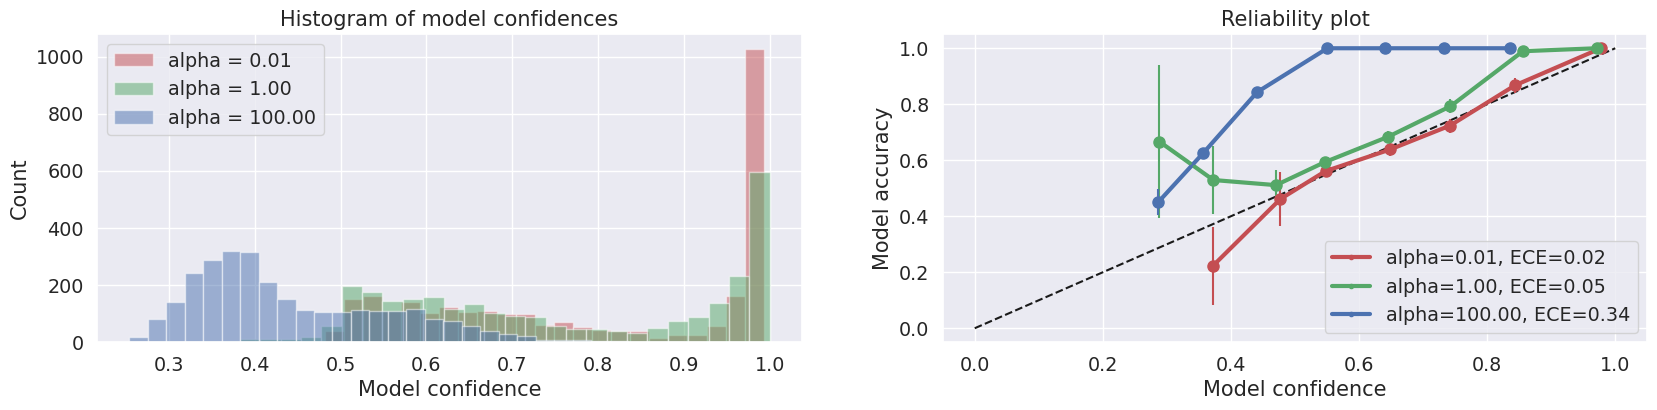

In [21]:
def compute_calibration_curve(ytrue, yhat, probs, num_bins=10):

    # create bins
    bins = jnp.linspace(0, 1, num_bins+1)

    # compute identify correct predictions and compute confidence
    correct_all = 1.0*(ytrue == yhat)
    conf_all = compute_confidence(probs)

    # preallocate lists
    acc_bin, acc_bin_se, conf_bin, point_in_bins = [], [], [], []

    # loop through each bin
    for i in range(num_bins):
        bin_start, bin_end = bins[i], bins[i+1]        
        bin_idx = jnp.logical_and(bin_start <= conf_all, conf_all < bin_end)
        num_points_in_bin = jnp.sum(bin_idx)

        # don't want to bother with empty bins
        if len(correct_all[bin_idx]) == 0:
            continue
        
        # compute results per bin
        conf_bin.append(jnp.mean(conf_all[bin_idx]))
        acc = jnp.mean(correct_all[bin_idx])
        acc_bin.append(acc)
        acc_bin_se.append(jnp.sqrt(acc*(1-acc)/num_points_in_bin))
        point_in_bins.append(len(correct_all[bin_idx]))

    # convert to JaX arrays
    acc_bin = jnp.array(acc_bin)
    acc_bin_se = jnp.array(acc_bin_se)
    conf_bin = jnp.array(conf_bin)
    point_in_bins = jnp.array(point_in_bins)

    # compute ECE
    ECE = jnp.sum(point_in_bins*jnp.abs(acc_bin-conf_bin))/len(ytrue)

        
    return ECE, acc_bin, acc_bin_se, conf_bin, point_in_bins

# specify list of alphas
alphas = [1e-2, 1., 1e2]

# prep plot
fig, ax = plt.subplots(1, 2, figsize=(20, 4))
ax[1].plot([0, 1], [0, 1], 'k--')

def design_matrix(X):
    return jnp.column_stack((jnp.ones(len(X)), X))

for i, alpha in enumerate(alphas):

    # fit model and compute posterior predictive probabilities and predictions (under the 0/1 utility function)
    model = BayesianLinearSoftmax(X_train, ytrain, alpha=alpha)
    ptest = model.predict_y(X_test, 1000)
    ytest_hat = jnp.argmax(ptest, 1)

    ECE, acc, acc_se, conf, num = compute_calibration_curve(ytest, ytest_hat, ptest)
    ax[0].hist(compute_confidence(ptest), 30, alpha=0.5, label=f'alpha = {alpha:3.2f}', color=colors[i])
    ax[1].plot(conf, acc, '.-', label=f'alpha={alpha:3.2f}, ECE={ECE:3.2f}', linewidth=3, color=colors[i])
    ax[1].errorbar(conf, acc, acc_se, color=colors[i], marker='o', markersize=8)


ax[0].set(xlabel='Model confidence', ylabel='Count', title='Histogram of model confidences')
ax[1].set(xlabel='Model confidence', ylabel='Model accuracy', title='Reliability plot')
ax[0].legend()
ax[1].legend()

**End of solution**